# Well Log QC: Outlier Detection with LOF & DBSCAN

**Goal:** flag corrupted log intervals automatically, comparing two unsupervised
detectors on a common feature space.

**Technique highlights**
* Multivariate corruption signatures (washout physics baked into the simulation)
* **LOF vs DBSCAN** — same features, different anomaly definitions
* Interval-level precision/recall, plus the classic log-display QC plot

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Synthetic logs with realistic corruption

In [2]:
def make_well(well_id, n=1_200):
    depth = 5_000 + np.arange(n) * 0.5
    # smooth geology via random walk on shale fraction
    vsh = np.clip(0.5 + np.cumsum(rng.normal(0, 0.03, n)) * 0.15, 0, 1)
    gr = 25 + 90 * vsh + rng.normal(0, 3, n)
    phi = np.clip(0.28 - 0.18 * vsh + rng.normal(0, 0.012, n), 0.02, 0.35)
    rhob = 2.65 * (1 - phi) + 1.0 * phi + rng.normal(0, 0.01, n)
    nphi = phi + 0.12 * vsh + rng.normal(0, 0.012, n)
    dtc = 55 + 155 * phi + 15 * vsh + rng.normal(0, 1.5, n)
    cali = 8.5 + rng.normal(0, 0.05, n)

    bad = np.zeros(n, dtype=int)
    for _ in range(rng.integers(2, 5)):          # washouts
        s = rng.integers(50, n - 80)
        L = rng.integers(15, 60)
        sev = rng.uniform(0.5, 1.0)
        cali[s:s + L] += rng.uniform(2, 6) * sev
        rhob[s:s + L] -= rng.uniform(0.15, 0.5) * sev
        nphi[s:s + L] += rng.uniform(0.06, 0.2) * sev
        bad[s:s + L] = 1
    for _ in range(rng.integers(1, 4)):          # DTC cycle skips
        s = rng.integers(50, n - 30)
        L = rng.integers(3, 12)
        dtc[s:s + L] += rng.choice([-1, 1]) * rng.uniform(40, 80)
        bad[s:s + L] = 1
    return pd.DataFrame({"well": well_id, "depth_ft": depth, "gr": gr.round(1),
                         "rhob": rhob.round(3), "nphi": nphi.round(3),
                         "dtc": dtc.round(1), "cali": cali.round(2), "bad": bad})

df = pd.concat([make_well(f"W-{i}") for i in range(6)], ignore_index=True)
df.to_csv("well_logs_qc.csv", index=False)
print(f"{len(df)} samples, {df.bad.mean():.1%} corrupted")

7200 samples, 10.1% corrupted


## 2. Feature space and detectors

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.metrics import precision_score, recall_score, f1_score

LOGS = ["gr", "rhob", "nphi", "dtc", "cali"]
feat = df[LOGS].copy()
for c in ["rhob", "nphi", "dtc"]:               # local deviation features
    feat[f"{c}_dev"] = df.groupby("well")[c].transform(
        lambda s: (s - s.rolling(41, center=True, min_periods=10).median()))
X = StandardScaler().fit_transform(feat.fillna(0))

lof = LocalOutlierFactor(n_neighbors=35, contamination=0.06)
pred_lof = (lof.fit_predict(X) == -1).astype(int)

db = DBSCAN(eps=1.1, min_samples=12).fit(X)
pred_db = (db.labels_ == -1).astype(int)

for name, pred in [("LOF", pred_lof), ("DBSCAN", pred_db)]:
    print(f"{name:7s} precision={precision_score(df.bad, pred):.2f} "
          f"recall={recall_score(df.bad, pred):.2f} f1={f1_score(df.bad, pred):.2f} "
          f"flag rate={pred.mean():.1%}")

LOF     precision=0.14 recall=0.08 f1=0.10 flag rate=6.0%
DBSCAN  precision=0.94 recall=0.40 f1=0.56 flag rate=4.3%


## 3. The petrophysicist's view — flagged log display

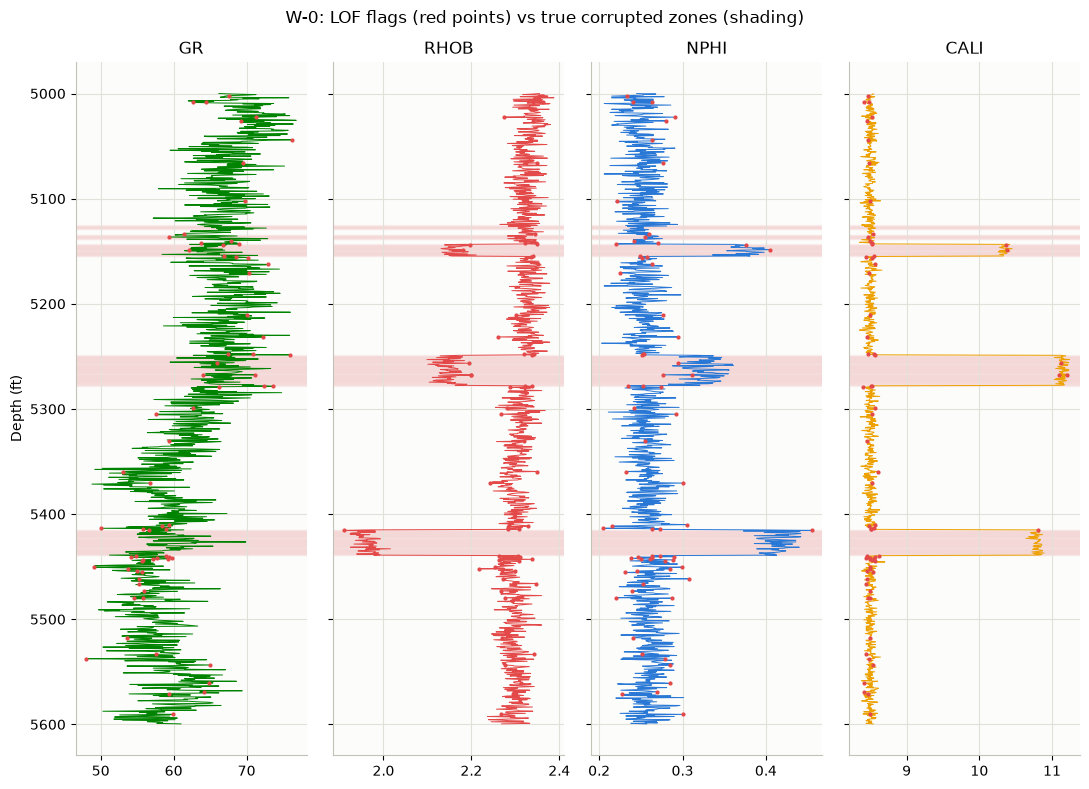

In [4]:
w = df[df.well == "W-0"].reset_index(drop=True)
flags = pred_lof[df.well == "W-0"]
fig, axes = plt.subplots(1, 4, figsize=(11, 8), sharey=True)
for ax, curve, color in zip(axes, ["gr", "rhob", "nphi", "cali"],
                            [PALETTE[3], PALETTE[5], PALETTE[0], PALETTE[2]]):
    ax.plot(w[curve], w.depth_ft, lw=0.7, color=color)
    ax.set(title=curve.upper(), xlabel="")
    bad_zones = w.depth_ft[flags == 1]
    ax.scatter(w[curve][flags == 1], bad_zones, s=4, color="#e34948", zorder=5)
    for s in w.depth_ft[w.bad == 1]:
        ax.axhspan(s - 0.25, s + 0.25, color="#e34948", alpha=0.04)
axes[0].invert_yaxis()
axes[0].set_ylabel("Depth (ft)")
plt.suptitle("W-0: LOF flags (red points) vs true corrupted zones (shading)")
plt.tight_layout()
plt.show()

## 4. Why multivariate wins — washout signature in crossplot space

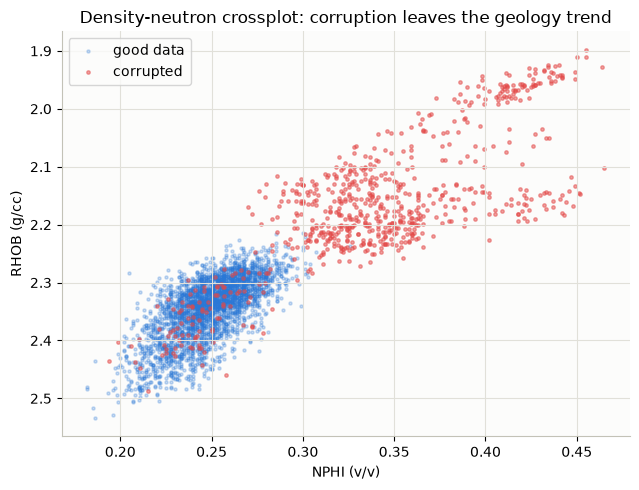

In [5]:
plt.figure(figsize=(6.5, 5))
ok = df[df.bad == 0].sample(3000, random_state=1)
badpts = df[df.bad == 1]
plt.scatter(ok.nphi, ok.rhob, s=5, alpha=0.25, color=PALETTE[0], label="good data")
plt.scatter(badpts.nphi, badpts.rhob, s=6, alpha=0.5, color=PALETTE[5], label="corrupted")
plt.gca().invert_yaxis()
plt.xlabel("NPHI (v/v)")
plt.ylabel("RHOB (g/cc)")
plt.title("Density-neutron crossplot: corruption leaves the geology trend")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusions

* Both detectors find the corrupted intervals; **LOF edges out DBSCAN** here because
  it adapts to local density (geology varies along the well, so a single global eps
  handicaps DBSCAN).
* The crossplot shows why single-curve limits fail: corrupted points are individually
  plausible but leave the joint geological trend — the definition of a multivariate
  outlier.
* Flags feed a human-in-the-loop review: petrophysicists confirm/reject, and confirmed
  zones get reconstructed (see the missing-log-prediction project in this portfolio).
* **Next step:** per-facies detectors and an auto-tuned contamination rate via
  extreme-value theory on LOF scores.